In [ ]:
# ============================================
# Mumbai Local - EDA (Exploratory Data Analysis)
# Step 2: Data Samajhna
# ============================================

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ============================================
# PHASE 1 — DATA LOAD KARO... PEHLI NAZAR
# ============================================
# Kyun? → Pehle confirm karo ki data sahi load hua
#          Rows, columns, data types sab check karo

print("=" * 50)
print("PHASE 1 — FIRST LOOK AT THE DATA")
print("=" * 50)

# Data load karo
df = pd.read_csv("data/mumbai_local_crowd_data.csv")

print(f"\n✅ Data Loaded Successfully!")
print(f"📊 Total Rows    : {len(df):,}")
print(f"📋 Total Columns : {len(df.columns)}")

# Columns ke naam
print(f"\n📌 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

# Pehle 5 rows dekho
print(f"\n👀 First 5 Rows:")
print(df.head())

# Data types check karo
# Kyun? → Number wala column text mein toh nahi?
print(f"\n🔍 Data Type of Each Column:")
print(df.dtypes)

PHASE 1 — FIRST LOOK AT THE DATA

✅ Data Loaded Successfully!
📊 Total Rows    : 709,560
📋 Total Columns : 13

📌 Column Names:
   1. date
   2. day_of_week
   3. day_name
   4. hour
   5. month
   6. is_monsoon
   7. is_holiday
   8. line
   9. station_from
   10. station_to
   11. train_type
   12. coach_number
   13. crowd_percent

👀 First 5 Rows:
         date  day_of_week day_name  hour  month  is_monsoon  is_holiday  \
0  01-01-2023            6   Sunday     6      1           0           0   
1  01-01-2023            6   Sunday     6      1           0           0   
2  01-01-2023            6   Sunday     6      1           0           0   
3  01-01-2023            6   Sunday     6      1           0           0   
4  01-01-2023            6   Sunday     6      1           0           0   

      line station_from station_to train_type  coach_number  crowd_percent  
0  Western     Borivali    Dahisar       Fast             1           5.00  
1  Western     Borivali    Dahisar    

In [ ]:
# ============================================
# PHASE 2 — NULL VALUES CHECK
# ============================================
# Kyun? → Agar koi value missing hai toh
#          ML model galat seekhega
#          Pehle hi pata hona chahiye

print("\n" + "=" * 50)
print("PHASE 2 — NULL VALUES CHECK")
print("=" * 50)

null_counts = df.isnull().sum()
print(f"\n🔍 Null Values in Each Column:")
print(null_counts)

if null_counts.sum() == 0:
    print("\n✅ No Null Values Found — Data is Clean!")
else:
    print(f"\n⚠️  Total Null Values: {null_counts.sum()}")


# ============================================
# Duplicate rows check karo
# ============================================
# Kyun? → Same data 2 baar hoga toh model
#          uss pattern ko zyada seekhega

duplicates = df.duplicated().sum()
print(f"\n🔍 Duplicate Rows: {duplicates}")
if duplicates == 0:
    print("✅ No Duplicates Found!")


PHASE 2 — NULL VALUES CHECK

🔍 Null Values in Each Column:
date             0
day_of_week      0
day_name         0
hour             0
month            0
is_monsoon       0
is_holiday       0
line             0
station_from     0
station_to       0
train_type       0
coach_number     0
crowd_percent    0
dtype: int64

✅ No Null Values Found — Data is Clean!

🔍 Duplicate Rows: 16


In [ ]:
# ============================================
# PHASE 3 — NUMBERS KO SAMJHO (Statistics)
# ============================================
# Kyun? → Crowd % ki range kya hai?
#          Average kitna hai? Max kitna?
#          Koi weird value toh nahi?

print("\n" + "=" * 50)
print("PHASE 3 — CROWD % STATISTICS")
print("=" * 50)

stats = df['crowd_percent'].describe()
print(f"""
📈 Crowd Percentage Analysis:
━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total Records  : {stats['count']:,.0f}
Average Crowd  : {stats['mean']:.2f}%
Minimum Crowd  : {stats['min']:.2f}%
Maximum Crowd  : {stats['max']:.2f}%
━━━━━━━━━━━━━━━━━━━━━━━━━━━
Bottom 25% trains have less than : {stats['25%']:.2f}% crowd
Bottom 50% trains have less than : {stats['50%']:.2f}% crowd
Bottom 75% trains have less than : {stats['75%']:.2f}% crowd
""")

# Crowd categories count karo
# Kyun? → Kitni trains Low/Medium/High hain?
df['crowd_category'] = pd.cut(
    df['crowd_percent'],
    bins=[0, 40, 70, 100],
    labels=['Low 🟢', 'Medium 🟡', 'High 🔴']
)

category_counts = df['crowd_category'].value_counts()
print("📊 Crowd Category Distribution:")
for cat, count in category_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   {cat}: {count:,} records ({percentage:.1f}%)")



PHASE 3 — CROWD % STATISTICS

📈 Crowd Percentage Analysis:
━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total Records  : 709,560
Average Crowd  : 31.17%
Minimum Crowd  : 5.00%
Maximum Crowd  : 100.00%
━━━━━━━━━━━━━━━━━━━━━━━━━━━
Bottom 25% trains have less than : 16.13% crowd
Bottom 50% trains have less than : 27.64% crowd
Bottom 75% trains have less than : 44.18% crowd

📊 Crowd Category Distribution:
   Low 🟢: 492,653 records (69.4%)
   Medium 🟡: 195,953 records (27.6%)
   High 🔴: 20,954 records (3.0%)


In [ ]:
# ============================================
# PHASE 4 — LINE WISE ANALYSIS
# ============================================
print("\n" + "=" * 50)
print("PHASE 4 — LINE WISE ANALYSIS")
print("=" * 50)

line_stats = df.groupby('line')['crowd_percent'].agg([
    'mean', 'max', 'min', 'count'
]).round(2)
line_stats.columns = ['Avg Crowd%', 'Max Crowd%',
                       'Min Crowd%', 'Total Records']
print("\n📊 Average Crowd Per Railway Line:")
print(line_stats)


PHASE 4 — LINE WISE ANALYSIS

📊 Average Crowd Per Railway Line:
         Avg Crowd%  Max Crowd%  Min Crowd%  Total Records
line                                                      
Central       32.77       96.74         5.0         236520
Harbour       25.73       78.04         5.0         236520
Western       35.01      100.00         5.0         236520


In [ ]:
# ============================================
# PHASE 5 — TIME WISE ANALYSIS
# ============================================
print("\n" + "=" * 50)
print("PHASE 5 — HOUR WISE ANALYSIS")
print("=" * 50)

hourly_crowd = df.groupby('hour')['crowd_percent'].mean().round(2)
print("\n⏰ Average Crowd Per Hour:")
peak_hour = hourly_crowd.idxmax()
lowest_hour = hourly_crowd.idxmin()
print(f"   🔴 Highest Crowd Hour : {peak_hour}:00  "
      f"({hourly_crowd[peak_hour]:.1f}%)")
print(f"   🟢 Lowest Crowd Hour  : {lowest_hour}:00  "
      f"({hourly_crowd[lowest_hour]:.1f}%)")


PHASE 5 — HOUR WISE ANALYSIS

⏰ Average Crowd Per Hour:
   🔴 Highest Crowd Hour : 8:00  (46.6%)
   🟢 Lowest Crowd Hour  : 6:00  (9.3%)


In [ ]:
# ============================================
# PHASE 6 — DAY WISE ANALYSIS
# ============================================
print("\n" + "=" * 50)
print("PHASE 6 — DAY WISE ANALYSIS")
print("=" * 50)

day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
day_crowd = df.groupby('day_name')['crowd_percent'].mean()
day_crowd = day_crowd.reindex(day_order).round(2)
print("\n📅 Average Crowd Per Day:")
for day, crowd in day_crowd.items():
    bar = "█" * int(crowd / 5)
    print(f"   {day:<12}: {crowd:>5.1f}%  {bar}")


PHASE 6 — DAY WISE ANALYSIS

📅 Average Crowd Per Day:
   Monday      :  36.4%  ███████
   Tuesday     :  34.6%  ██████
   Wednesday   :  34.2%  ██████
   Thursday    :  34.3%  ██████
   Friday      :  36.0%  ███████
   Saturday    :  26.1%  █████
   Sunday      :  16.9%  ███


In [ ]:
# ============================================
# PHASE 7 — MONSOON EFFECT
# ============================================
print("\n" + "=" * 50)
print("PHASE 7 — MONSOON EFFECT ANALYSIS")
print("=" * 50)

monsoon_effect = df.groupby('is_monsoon')['crowd_percent'].mean().round(2)
normal_crowd  = monsoon_effect[0]
monsoon_crowd = monsoon_effect[1]
difference    = monsoon_crowd - normal_crowd

print(f"""
🌧️  Impact of Monsoon on Crowd:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Normal Season  : {normal_crowd:.2f}%
Monsoon Season : {monsoon_crowd:.2f}%
Difference     : +{difference:.2f}%

Monsoon adds {difference:.1f}% extra crowd
because people avoid road travel during rain! 🌧️
""")



PHASE 7 — MONSOON EFFECT ANALYSIS

🌧️  Impact of Monsoon on Crowd:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Normal Season  : 29.36%
Monsoon Season : 34.80%
Difference     : +5.44%

Monsoon adds 5.4% extra crowd
because people avoid road travel during rain! 🌧️



In [ ]:
# ============================================
# PHASE 8 — TRAIN TYPE ANALYSIS
# ============================================
print("\n" + "=" * 50)
print("PHASE 8 — TRAIN TYPE ANALYSIS")
print("=" * 50)

train_crowd = df.groupby('train_type')['crowd_percent'].mean().round(2)
print("\n🚆 Average Crowd by Train Type:")
for train, crowd in train_crowd.sort_values(ascending=False).items():
    bar = "█" * int(crowd / 5)
    print(f"   {train:<12}: {crowd:.1f}%  {bar}")


PHASE 8 — TRAIN TYPE ANALYSIS

🚆 Average Crowd by Train Type:
   Fast        : 36.4%  ███████
   Semi-Fast   : 31.7%  ██████
   Slow        : 25.4%  █████


In [ ]:
# ============================================
# PHASE 9 — COACH WISE ANALYSIS
# ============================================
print("\n" + "=" * 50)
print("PHASE 9 — COACH WISE ANALYSIS")
print("=" * 50)

coach_crowd = df.groupby('coach_number')['crowd_percent'].mean().round(2)
print("\n🚃 Average Crowd Per Coach:")
for coach, crowd in coach_crowd.items():
    bar = "█" * int(crowd / 5)
    status = "✅ Best" if crowd < 40 else "⚠️ Medium" if crowd < 70 else "🔴 Crowded"
    print(f"   Coach {coach:>2}: {crowd:.1f}%  {bar}  {status}")


PHASE 9 — COACH WISE ANALYSIS

🚃 Average Crowd Per Coach:
   Coach  1: 24.4%  ████  ✅ Best
   Coach  2: 28.9%  █████  ✅ Best
   Coach  3: 32.5%  ██████  ✅ Best
   Coach  4: 32.5%  ██████  ✅ Best
   Coach  5: 34.3%  ██████  ✅ Best
   Coach  6: 34.3%  ██████  ✅ Best
   Coach  7: 34.3%  ██████  ✅ Best
   Coach  8: 34.3%  ██████  ✅ Best
   Coach  9: 32.5%  ██████  ✅ Best
   Coach 10: 32.5%  ██████  ✅ Best
   Coach 11: 28.9%  █████  ✅ Best
   Coach 12: 24.4%  ████  ✅ Best


In [ ]:
# ============================================
# PHASE 10 — GRAPHS BANANA (Plotly)
# ============================================
# Kyun? → Numbers padh ke interviewer impress
#          nahi hoga, graphs se hoga!

print("\n" + "=" * 50)
print("PHASE 10 — GENERATING GRAPHS...")
print("=" * 50)


PHASE 10 — GENERATING GRAPHS...


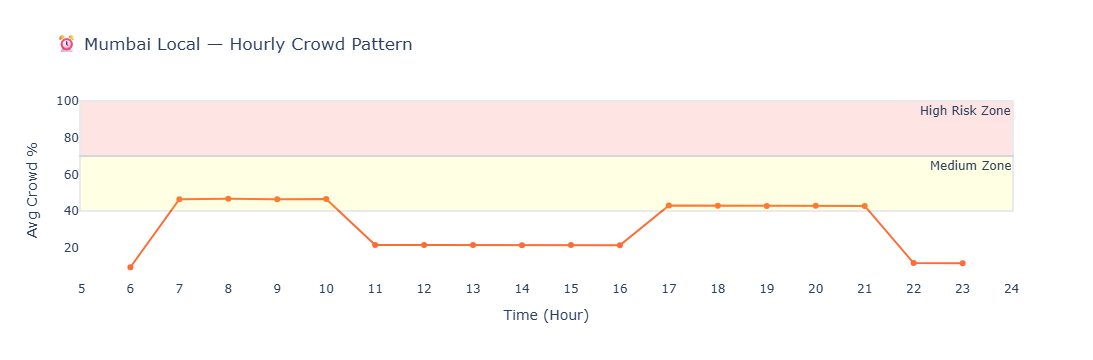

✅ Graph 1 Done : Hourly Crowd Pattern


In [ ]:
# --- GRAPH 1: Hourly Crowd Pattern ---
hourly_data = df.groupby('hour')['crowd_percent'].mean().reset_index()

fig1 = px.line(
    hourly_data,
    x='hour',
    y='crowd_percent',
    title='⏰ Mumbai Local — Hourly Crowd Pattern',
    labels={'hour': 'Time (Hour)', 'crowd_percent': 'Avg Crowd %'},
    markers=True,
    color_discrete_sequence=['#FF6B35']
)
fig1.add_hrect(y0=70, y1=100, fillcolor="red",
               opacity=0.1, annotation_text="High Risk Zone")
fig1.add_hrect(y0=40, y1=70, fillcolor="yellow",
               opacity=0.1, annotation_text="Medium Zone")
fig1.update_layout(
    plot_bgcolor='white',
    xaxis=dict(tickmode='linear', dtick=1)
)
fig1.show()
print("✅ Graph 1 Done : Hourly Crowd Pattern")

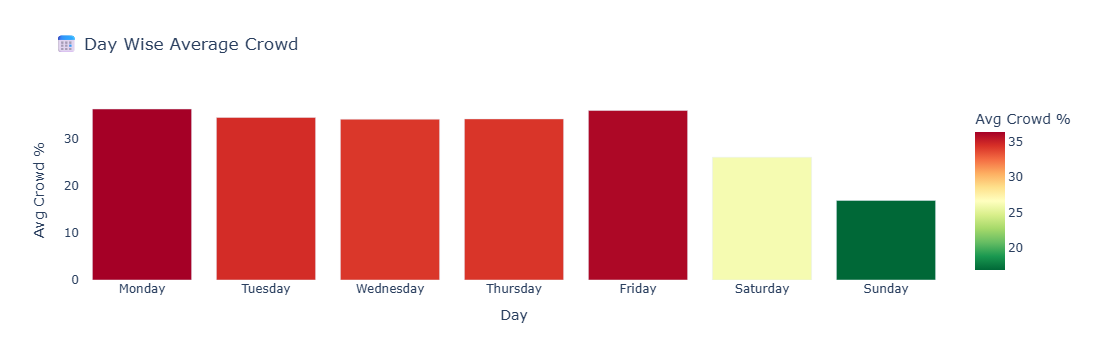

✅ Graph 2 Done : Day Wise Crowd


In [ ]:
# --- GRAPH 2: Day Wise Bar Chart ---
day_data = df.groupby('day_name')['crowd_percent'].mean().reset_index()
day_data['day_name'] = pd.Categorical(
    day_data['day_name'], categories=day_order, ordered=True
)
day_data = day_data.sort_values('day_name')

fig2 = px.bar(
    day_data,
    x='day_name',
    y='crowd_percent',
    title='📅 Day Wise Average Crowd',
    labels={'day_name': 'Day', 'crowd_percent': 'Avg Crowd %'},
    color='crowd_percent',
    color_continuous_scale='RdYlGn_r'
)
fig2.update_layout(plot_bgcolor='white')
fig2.show()
print("✅ Graph 2 Done : Day Wise Crowd")


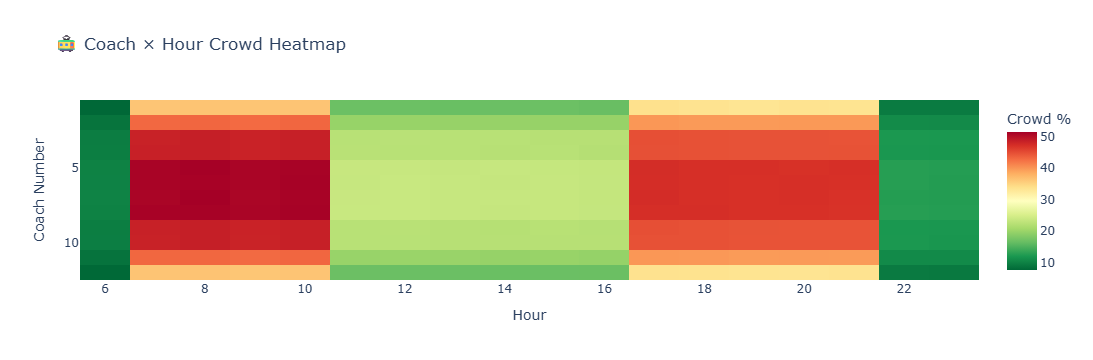

✅ Graph 3 Done : Coach Heatmap


In [ ]:
# --- GRAPH 3: Coach Heatmap ---
coach_hour = df.groupby(['coach_number', 'hour'])[
    'crowd_percent'].mean().reset_index()
coach_pivot = coach_hour.pivot(
    index='coach_number',
    columns='hour',
    values='crowd_percent'
)

fig3 = px.imshow(
    coach_pivot,
    title='🚃 Coach × Hour Crowd Heatmap',
    labels=dict(x='Hour', y='Coach Number',
                color='Crowd %'),
    color_continuous_scale='RdYlGn_r',
    aspect='auto'
)
fig3.show()
print("✅ Graph 3 Done : Coach Heatmap")

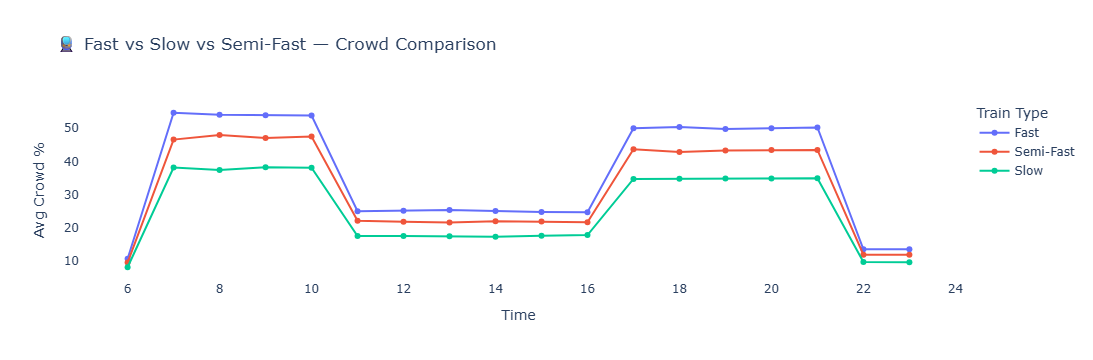

✅ Graph 4 Done : Train Type Comparison


In [ ]:
# --- GRAPH 4: Train Type Comparison ---
train_data = df.groupby(
    ['train_type', 'hour'])['crowd_percent'].mean().reset_index()

fig4 = px.line(
    train_data,
    x='hour',
    y='crowd_percent',
    color='train_type',
    title='🚆 Fast vs Slow vs Semi-Fast — Crowd Comparison',
    labels={'hour': 'Time', 'crowd_percent': 'Avg Crowd %',
            'train_type': 'Train Type'},
    markers=True
)
fig4.update_layout(plot_bgcolor='white')
fig4.show()
print("✅ Graph 4 Done : Train Type Comparison")

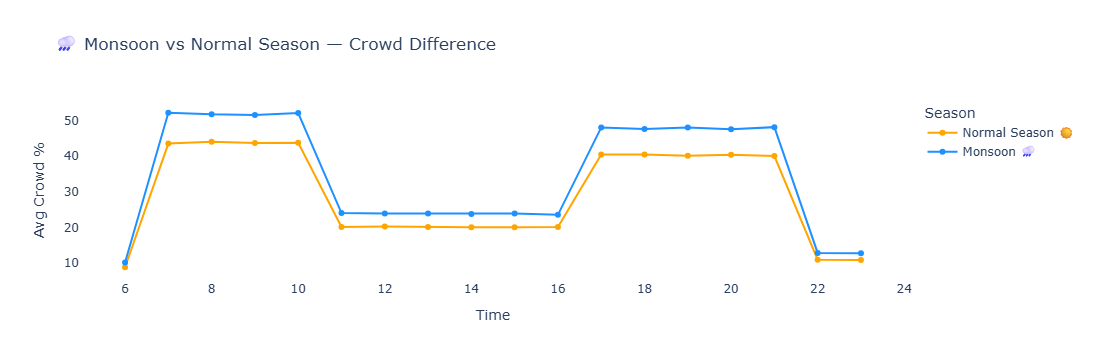

✅ Graph 5 Done : Monsoon Effect


In [ ]:
# --- GRAPH 5: Monsoon vs Normal ---
monsoon_data = df.groupby(
    ['is_monsoon', 'hour'])['crowd_percent'].mean().reset_index()
monsoon_data['Season'] = monsoon_data['is_monsoon'].map(
    {0: 'Normal Season ☀️', 1: 'Monsoon 🌧️'}
)

fig5 = px.line(
    monsoon_data,
    x='hour',
    y='crowd_percent',
    color='Season',
    title='🌧️ Monsoon vs Normal Season — Crowd Difference',
    labels={'hour': 'Time', 'crowd_percent': 'Avg Crowd %'},
    markers=True,
    color_discrete_map={
        'Normal Season ☀️': '#FFA500',
        'Monsoon 🌧️': '#1E90FF'
    }
)
fig5.update_layout(plot_bgcolor='white')
fig5.show()
print("✅ Graph 5 Done : Monsoon Effect")

In [ ]:
# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "=" * 50)
print("✅ EDA COMPLETE — FINAL SUMMARY")
print("=" * 50)
print(f"""
📊 Dataset Size     : {len(df):,} rows, {len(df.columns)} columns
🔴 Null Values      : {df.isnull().sum().sum()}
📈 Average Crowd    : {df['crowd_percent'].mean():.1f}%
🕐 Peak Hour        : {hourly_crowd.idxmax()}:00
📅 Busiest Day      : {day_crowd.idxmax()}
🚆 Busiest Train    : {train_crowd.idxmax()}
🌧️  Monsoon Effect   : +{difference:.1f}% extra crowd

Next Step → ML Model Training! 🚀
""")


✅ EDA COMPLETE — FINAL SUMMARY

📊 Dataset Size     : 709,560 rows, 14 columns
🔴 Null Values      : 0
📈 Average Crowd    : 31.2%
🕐 Peak Hour        : 8:00
📅 Busiest Day      : Monday
🚆 Busiest Train    : Fast
🌧️  Monsoon Effect   : +5.4% extra crowd

Next Step → ML Model Training! 🚀

